# ショット雑音（Shot Noise）トイモデル

ショット雑音は「電荷が離散的に到着する」ことに由来する揺らぎです。
典型的には、到着イベントがポアソン過程で起きると仮定すると、平均電流が同じでも瞬間的にはパルス列になり、観測回路（帯域制限）を通すと雑音として見えます。

## トイモデル
- 到着イベント: ポアソン過程（到着率 `λ` [1/s]）
- 1イベントあたりの電荷: `q` [C]
- 観測系: 1次 RC（インパルス応答が指数関数）

このモデルでは、電流の“生”のパルス列 `i_raw(t)` を作り、RC を通した出力 `i_out(t)`（または電圧とみなしてもOK）を可視化します。

## 見るポイント
- `λ` を上げるほどイベントが密になり、平均化されて滑らかに見える
- RC の時定数 `τ` を大きくすると、パルスが重なって低域寄りの揺らぎになる

（※定量式の厳密な一致より、見た目の理解を優先した簡易モデルです。）


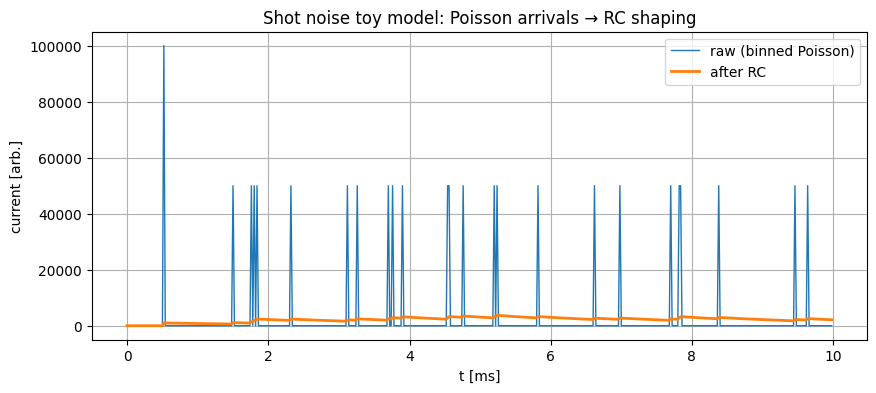

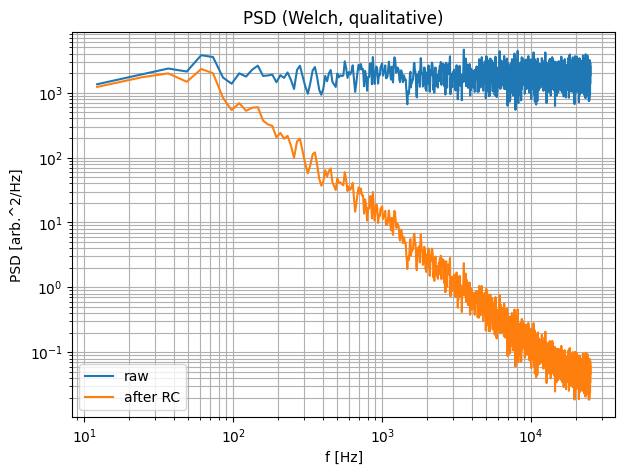

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ===== パラメータ =====
fs = 50_000.0       # サンプリング周波数 [Hz]
T = 0.5             # 観測時間 [s]
N = int(fs * T)
dt = 1.0 / fs

lam = 2_000.0       # 到着率 λ [1/s]
q = 1.0             # 1イベントあたりの電荷（任意単位でも可）

tau = 2e-3          # RC 時定数 [s]（大きいほど平滑化）

rng = np.random.default_rng(0)

# ===== イベント生成（各サンプル内の到着数 ~ Poisson(lam*dt)） =====
k = rng.poisson(lam * dt, size=N)
i_raw = q * k / dt  # 各ビンに入った電荷を電流に換算

# ===== RC（1次ローパス）で整形: y[n] = a y[n-1] + (1-a) x[n] =====
a = np.exp(-dt / tau)
i_out = np.empty_like(i_raw)
y = 0.0
for n in range(N):
    y = a * y + (1.0 - a) * i_raw[n]
    i_out[n] = y

t = dt * np.arange(N)

# ===== プロット（時間波形） =====
plt.figure(figsize=(10, 4))
m = int(0.02 * N)  # 最初の 2% だけ拡大表示
plt.plot(t[:m] * 1e3, i_raw[:m], lw=1, label="raw (binned Poisson)")
plt.plot(t[:m] * 1e3, i_out[:m], lw=2, label="after RC")
plt.xlabel("t [ms]")
plt.ylabel("current [arb.]")
plt.title("Shot noise toy model: Poisson arrivals → RC shaping")
plt.grid(True)
plt.legend()
plt.show()

# ===== PSD（簡易 Welch） =====
def welch_psd(x, fs, nperseg=4096, noverlap=2048):
    x = np.asarray(x)
    step = nperseg - noverlap
    if step <= 0:
        raise ValueError("noverlap must be < nperseg")
    w = np.hanning(nperseg)
    scale = fs * (w**2).sum()
    psd = None
    count = 0
    for start in range(0, len(x) - nperseg + 1, step):
        seg = x[start : start + nperseg]
        seg = seg - seg.mean()
        X = np.fft.rfft(seg * w)
        P = (np.abs(X) ** 2) / scale
        psd = P if psd is None else (psd + P)
        count += 1
    psd = psd / max(count, 1)
    f = np.fft.rfftfreq(nperseg, d=1.0 / fs)
    return f, psd

f, P_raw = welch_psd(i_raw, fs)
f, P_out = welch_psd(i_out, fs)

plt.figure(figsize=(7, 5))
plt.loglog(f[1:], P_raw[1:], label="raw")
plt.loglog(f[1:], P_out[1:], label="after RC")
plt.xlabel("f [Hz]")
plt.ylabel("PSD [arb.^2/Hz]")
plt.title("PSD (Welch, qualitative)")
plt.grid(True, which="both")
plt.legend()
plt.show()
